In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [2]:
sales_df = pd.read_csv("Advertising Budget and Sales.csv", index_col=0)
sales_df.head()

,TV Ad Budget ($),Radio Ad Budget ($),Newspaper Ad Budget ($),Sales ($)
1,230.1,37.8,69.2,22.1
2,44.5,39.3,45.1,10.4
3,17.2,45.9,69.3,9.3
4,151.5,41.3,58.5,18.5
5,180.8,10.8,58.4,12.9


In [3]:
print("Shape:", sales_df.shape)
print("\nColumn info:")
print(sales_df.info())
print("\nMissing values:\n", sales_df.isnull().sum())

Shape: (200, 4)

Column info:
<class 'pandas.DataFrame'>
RangeIndex: 200 entries, 1 to 200
Data columns (total 4 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   TV Ad Budget ($)         200 non-null    float64
 1   Radio Ad Budget ($)      200 non-null    float64
 2   Newspaper Ad Budget ($)  200 non-null    float64
 3   Sales ($)                200 non-null    float64
dtypes: float64(4)
memory usage: 6.4 KB
None

Missing values:
 TV Ad Budget ($)           0
Radio Ad Budget ($)        0
Newspaper Ad Budget ($)    0
Sales ($)                  0
dtype: int64


**Observation:** The dataset contains 200 advertising campaigns with 4 numeric columns
(TV, Radio, Newspaper ad budgets, and resulting Sales). There are no missing values,
so the dataset is ready for analysis without any cleaning.

In [4]:
sales_df.describe()

,TV Ad Budget ($),Radio Ad Budget ($),Newspaper Ad Budget ($),Sales ($)
count,200.000000,200.000000,200.000000,200.000000
mean,147.042500,23.264000,30.554000,14.022500
std,85.854236,14.846809,21.778621,5.217457
min,0.700000,0.000000,0.300000,1.600000
25%,74.375000,9.975000,12.750000,10.375000
50%,149.750000,22.900000,25.750000,12.900000
75%,218.825000,36.525000,45.100000,17.400000
max,296.400000,49.600000,114.000000,27.000000


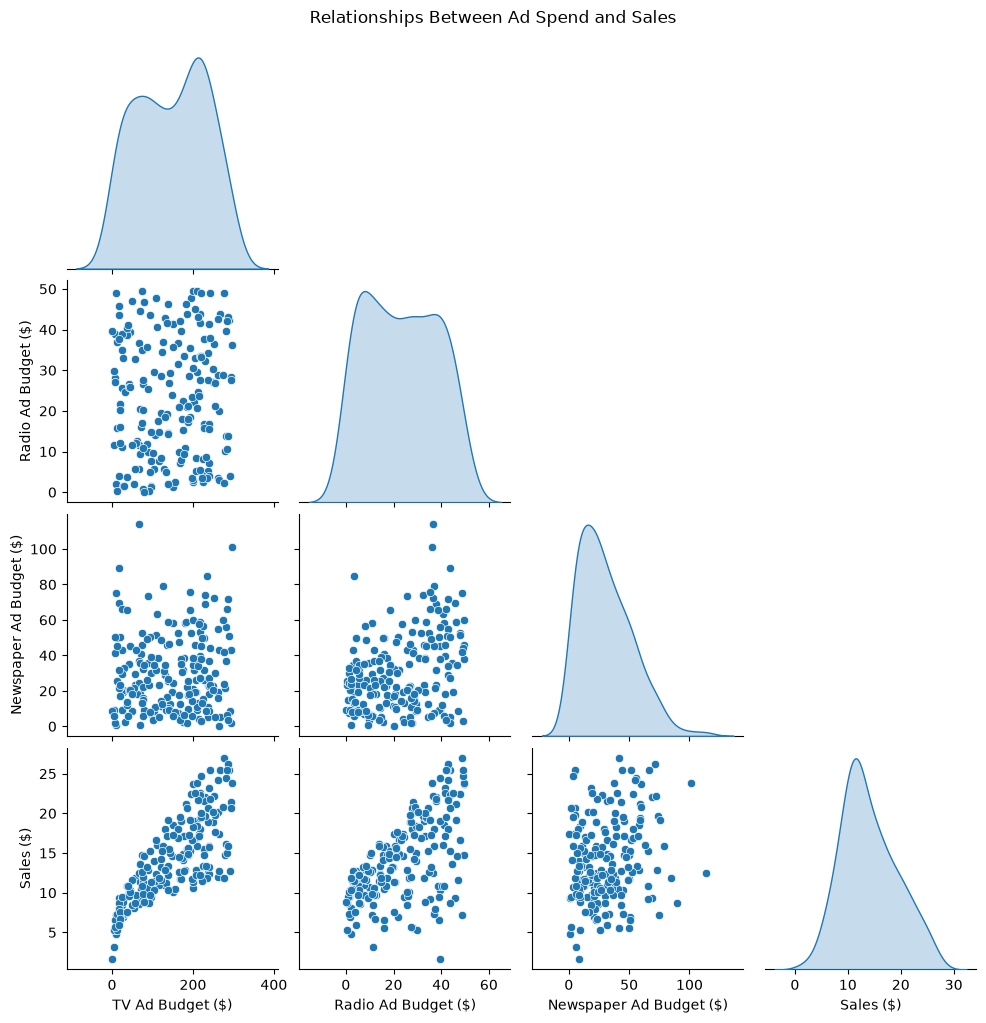

In [5]:
sns.pairplot(sales_df, diag_kind='kde', corner=True)
plt.suptitle("Relationships Between Ad Spend and Sales", y=1.02)
plt.show()

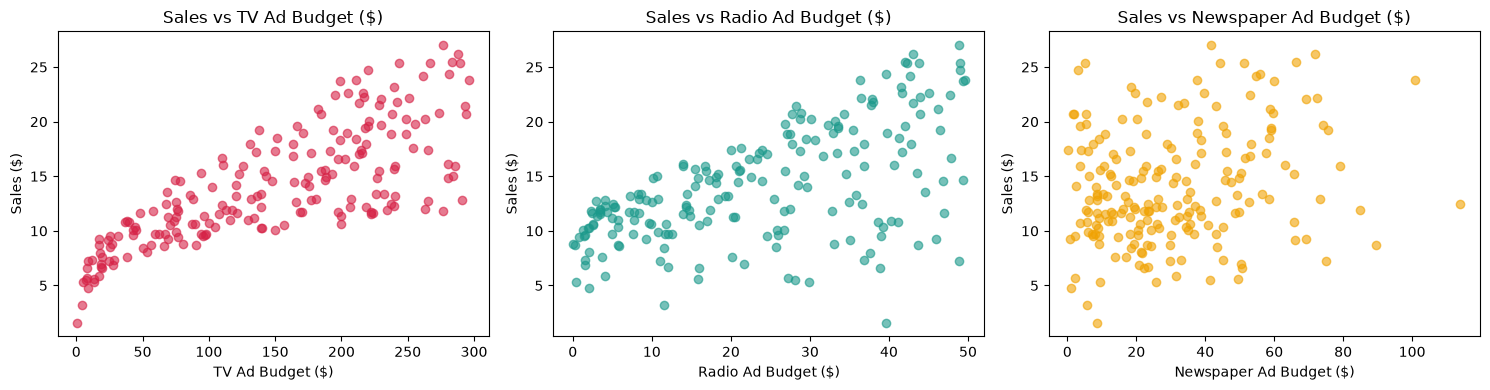

In [6]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

channels = ['TV Ad Budget ($)', 'Radio Ad Budget ($)', 'Newspaper Ad Budget ($)']
colors = ['#D62246', '#1B998B', '#F0A202']

for ax, channel, color in zip(axes, channels, colors):
    ax.scatter(sales_df[channel], sales_df['Sales ($)'], color=color, alpha=0.6)
    ax.set_xlabel(channel)
    ax.set_ylabel('Sales ($)')
    ax.set_title(f'Sales vs {channel}')

plt.tight_layout()
plt.show()

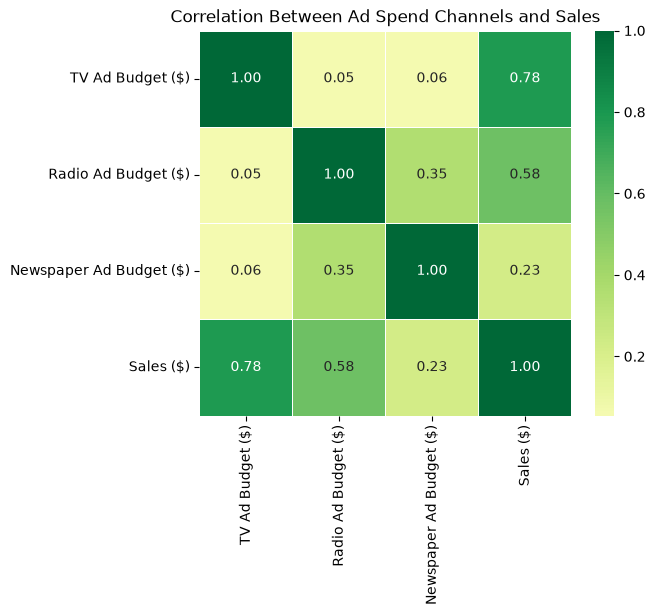

In [7]:
plt.figure(figsize=(6, 5))
corr_matrix = sales_df.corr()
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='RdYlGn', center=0, linewidths=0.5)
plt.title("Correlation Between Ad Spend Channels and Sales")
plt.show()

**Correlation Insight:** TV ad spend shows the strongest correlation with Sales (0.78),
followed by Radio (0.58). Newspaper ad spend shows a weak correlation with Sales (0.23),
suggesting it has little impact compared to the other two channels. This matches the
scatter plot findings — Newspaper spend didn't show a clear upward trend with Sales,
while TV did.


In [8]:
features = ['TV Ad Budget ($)', 'Radio Ad Budget ($)', 'Newspaper Ad Budget ($)']
X = sales_df[features]
y = sales_df['Sales ($)']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=7)

print("Training samples:", X_train.shape[0])
print("Testing samples:", X_test.shape[0])

Training samples: 160
Testing samples: 40


In [9]:
linreg_model = LinearRegression()
linreg_model.fit(X_train, y_train)
y_pred_linreg = linreg_model.predict(X_test)

print("Model trained successfully")
print("Coefficients:", dict(zip(features, linreg_model.coef_)))
print("Intercept:", linreg_model.intercept_)

Model trained successfully
Coefficients: {'TV Ad Budget ($)': np.float64(0.046297056609835976), 'Radio Ad Budget ($)': np.float64(0.18884253894004877), 'Newspaper Ad Budget ($)': np.float64(-0.001074945518874243)}
Intercept: 2.849935387313435


In [10]:
from sklearn.ensemble import GradientBoostingRegressor

gb_model = GradientBoostingRegressor(random_state=7)
gb_model.fit(X_train, y_train)
y_pred_gb = gb_model.predict(X_test)

print("Gradient Boosting model trained successfully")

Gradient Boosting model trained successfully


In [11]:
print("=== Linear Regression ===")
print("MAE:", mean_absolute_error(y_test, y_pred_linreg))
print("RMSE:", mean_squared_error(y_test, y_pred_linreg) ** 0.5)
print("R² Score:", r2_score(y_test, y_pred_linreg))

print("\n=== Gradient Boosting ===")
print("MAE:", mean_absolute_error(y_test, y_pred_gb))
print("RMSE:", mean_squared_error(y_test, y_pred_gb) ** 0.5)
print("R² Score:", r2_score(y_test, y_pred_gb))

=== Linear Regression ===
MAE: 1.1435743461463292
RMSE: 1.5585476273306489
R² Score: 0.9095550600904052

=== Gradient Boosting ===
MAE: 0.5323552636316449
RMSE: 0.653760409119824
R² Score: 0.984085926799723


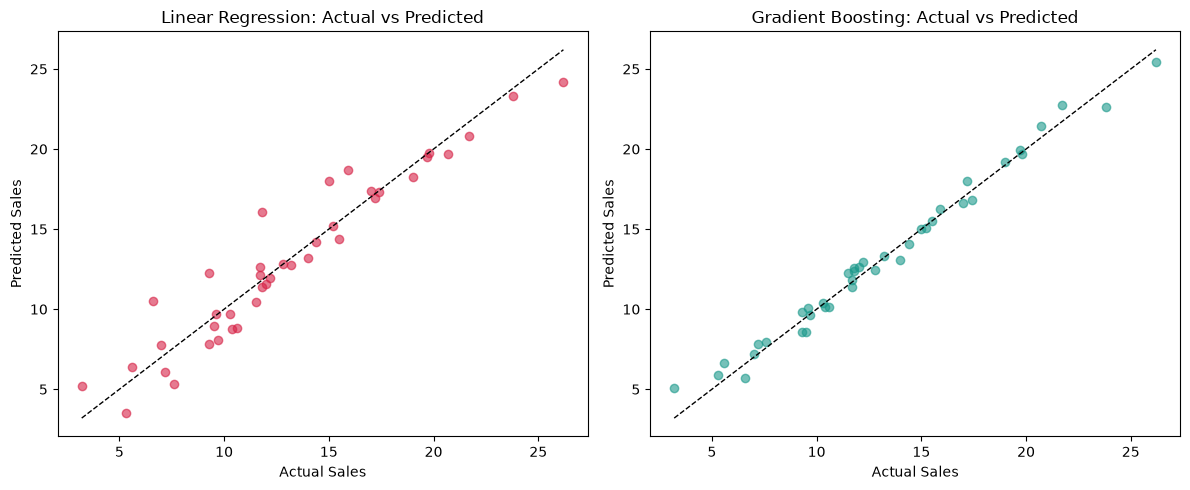

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].scatter(y_test, y_pred_linreg, color='#D62246', alpha=0.6)
axes[0].plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'k--', lw=1)
axes[0].set_xlabel("Actual Sales")
axes[0].set_ylabel("Predicted Sales")
axes[0].set_title("Linear Regression: Actual vs Predicted")

axes[1].scatter(y_test, y_pred_gb, color='#1B998B', alpha=0.6)
axes[1].plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'k--', lw=1)
axes[1].set_xlabel("Actual Sales")
axes[1].set_ylabel("Predicted Sales")
axes[1].set_title("Gradient Boosting: Actual vs Predicted")

plt.tight_layout()
plt.show()

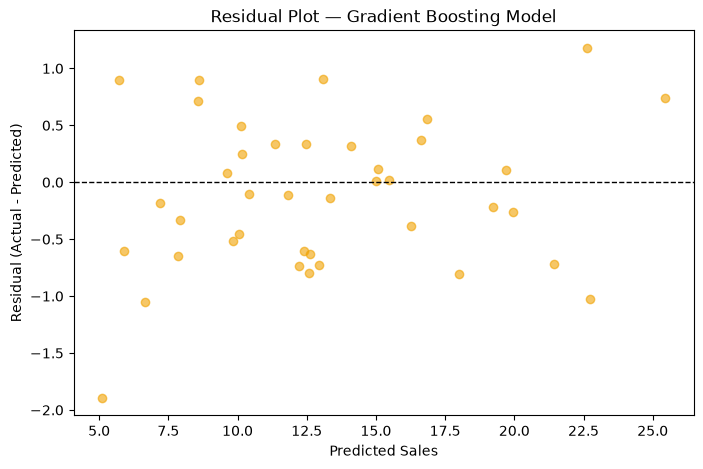

In [13]:
residuals = y_test - y_pred_gb

plt.figure(figsize=(8, 5))
plt.scatter(y_pred_gb, residuals, color='#F0A202', alpha=0.6)
plt.axhline(y=0, color='black', linestyle='--', lw=1)
plt.xlabel("Predicted Sales")
plt.ylabel("Residual (Actual - Predicted)")
plt.title("Residual Plot — Gradient Boosting Model")
plt.show()

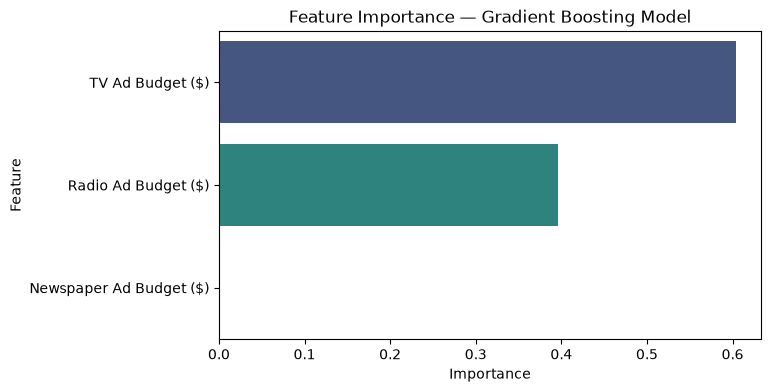

,Feature,Importance
0,TV Ad Budget ($),0.603531
1,Radio Ad Budget ($),0.395671
2,Newspaper Ad Budget ($),0.000798


In [14]:
importance_df = pd.DataFrame({
    'Feature': features,
    'Importance': gb_model.feature_importances_
}).sort_values('Importance', ascending=False)

plt.figure(figsize=(7, 4))
sns.barplot(data=importance_df, x='Importance', y='Feature', hue='Feature', palette='viridis', legend=False)
plt.title("Feature Importance — Gradient Boosting Model")
plt.show()

importance_df

## Conclusion

Both models were evaluated on their ability to predict sales from advertising spend:

| Model | MAE | RMSE | R² Score |
|---|---|---|---|
| Linear Regression | 1.14 | 1.56 | 0.91 |
| Gradient Boosting | 0.53 | 0.65 | 0.98 |

**Best model: Gradient Boosting Regressor**, achieving a 98% R² score and roughly half
the prediction error of Linear Regression. This suggests the true relationship between
ad spend and sales has some non-linear patterns that Gradient Boosting captures better
than a straight-line model.

### Key Findings
- **TV ad spend has by far the largest impact on sales** — confirmed independently through
  correlation analysis (0.78), scatter plot trends, and feature importance ranking.
- **Radio ad spend has a moderate impact** (correlation 0.58).
- **Newspaper ad spend has minimal impact on sales** (correlation 0.23) — of the three
  channels, this is the least effective use of advertising budget based on this dataset.

### Business Recommendation
If optimizing an advertising budget based on this data, prioritizing **TV advertising**
would likely yield the strongest returns, followed by Radio. Newspaper spend appears to
contribute little to sales and could be reduced or reallocated.